In [1]:
# DAY 17 - LOAN APPROVAL PREDICTION USING DECISION TREE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a small loan approval dataset

data = {
    "Income": [25000, 45000, 60000, 30000, 80000, 55000, 20000, 70000, 90000, 35000,
               50000, 75000, 28000, 65000, 40000],
    "Credit_Score": [580, 650, 720, 600, 780, 710, 550, 750, 800, 620,
                     680, 760, 570, 730, 640],
    "Loan_Amount": [200000, 150000, 100000, 250000, 200000, 120000, 300000, 150000, 100000, 200000,
                    180000, 150000, 250000, 120000, 180000],
    "Employment_Years": [1, 3, 5, 2, 8, 6, 1, 7, 10, 3,
                         4, 9, 2, 6, 3],
    "Loan_Approved": [0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
                      1, 1, 0, 1, 0]
}

loan_data = pd.DataFrame(data)

print("Loan dataset created successfully!")
print(loan_data)

Loan dataset created successfully!
    Income  Credit_Score  Loan_Amount  Employment_Years  Loan_Approved
0    25000           580       200000                 1              0
1    45000           650       150000                 3              1
2    60000           720       100000                 5              1
3    30000           600       250000                 2              0
4    80000           780       200000                 8              1
5    55000           710       120000                 6              1
6    20000           550       300000                 1              0
7    70000           750       150000                 7              1
8    90000           800       100000                10              1
9    35000           620       200000                 3              0
10   50000           680       180000                 4              1
11   75000           760       150000                 9              1
12   28000           570       250000     

In [3]:
# Separate features and target

X = loan_data[
    ["Income", "Credit_Score", "Loan_Amount", "Employment_Years"]
]

y = loan_data["Loan_Approved"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Income  Credit_Score  Loan_Amount  Employment_Years
0    25000           580       200000                 1
1    45000           650       150000                 3
2    60000           720       100000                 5
3    30000           600       250000                 2
4    80000           780       200000                 8
5    55000           710       120000                 6
6    20000           550       300000                 1
7    70000           750       150000                 7
8    90000           800       100000                10
9    35000           620       200000                 3
10   50000           680       180000                 4
11   75000           760       150000                 9
12   28000           570       250000                 2
13   65000           730       120000                 6
14   40000           640       180000                 3

Target:
0     0
1     1
2     1
3     0
4     1
5     1
6     0
7     1
8     1
9     0
10   

In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 4)
Testing data: (3, 4)


In [5]:
# Train the Decision Tree classifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [6]:
# Make predictions on the test data

y_pred = decision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred)
print("Actual values:", y_test.values)
print(f"Accuracy: {accuracy:.2f}")

Predictions: [0 1 1]
Actual values: [0 1 1]
Accuracy: 1.00


In [7]:
# Evaluate the Decision Tree model

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



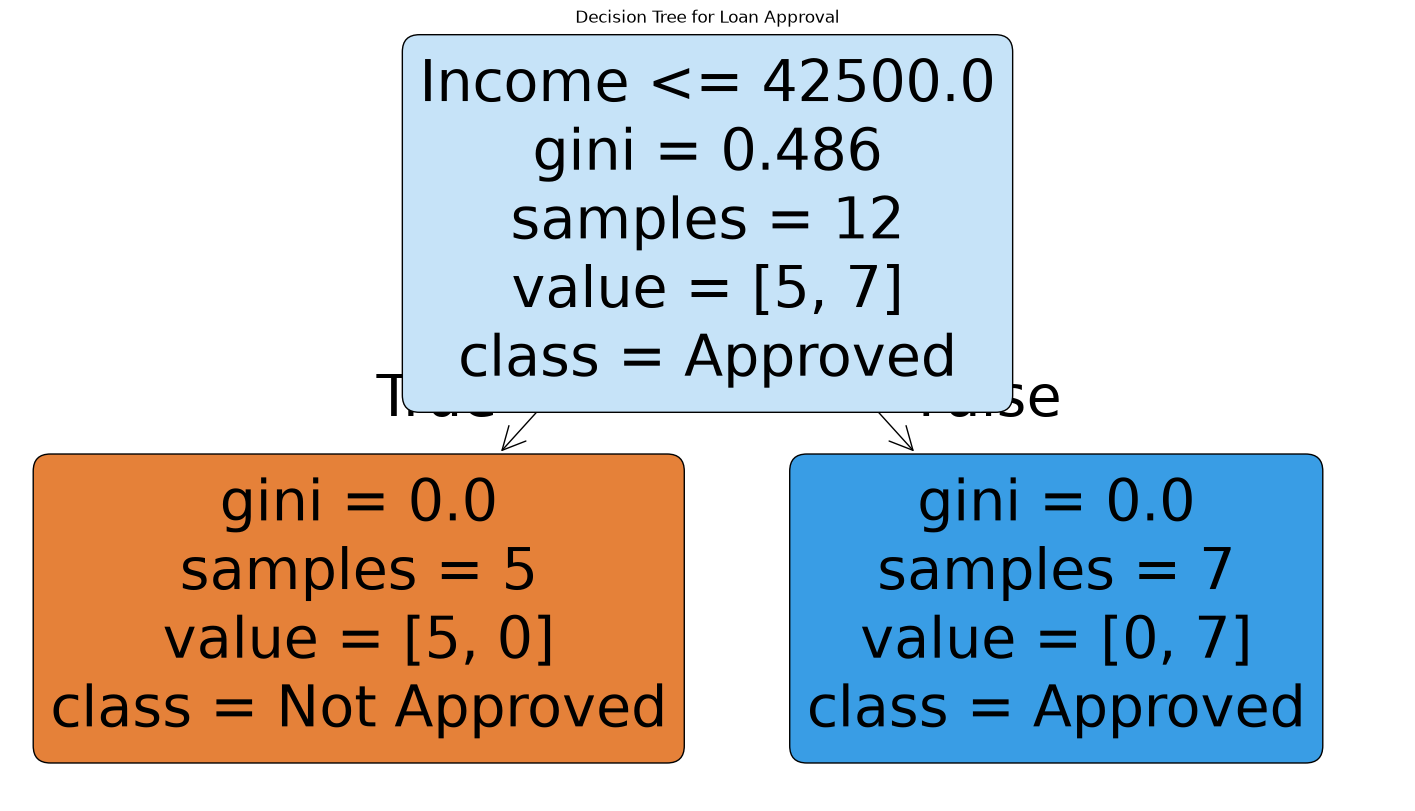

In [8]:
# Visualize the Decision Tree

plt.figure(figsize=(18, 10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Loan Approval")

plt.savefig(
    "decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Feature Importance:
            Feature  Importance
0            Income         1.0
1      Credit_Score         0.0
2       Loan_Amount         0.0
3  Employment_Years         0.0


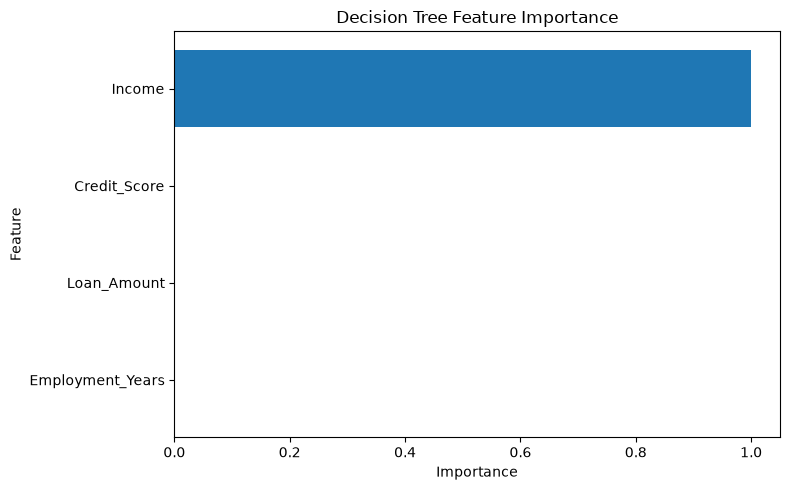

In [9]:
# Analyze feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importance:")
print(importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# Check training and testing accuracy

train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print("Training Accuracy:", round(train_accuracy, 3))
print("Testing Accuracy:", round(test_accuracy, 3))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [11]:
# Display the decision rules

from sklearn.tree import export_text

rules = export_text(
    decision_tree,
    feature_names=list(X.columns)
)

print("Decision Tree Rules:")
print(rules)

Decision Tree Rules:
|--- Income <= 42500.00
|   |--- class: 0
|--- Income >  42500.00
|   |--- class: 1



In [12]:
# Save prediction results

results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred

results.to_csv("loan_predictions.csv", index=False)

print("Prediction results saved successfully!")
print(results)

Prediction results saved successfully!
    Income  Credit_Score  Loan_Amount  Employment_Years  Actual  Predicted
9    35000           620       200000                 3       0          0
7    70000           750       150000                 7       1          1
10   50000           680       180000                 4       1          1
